# Notebook 1 | Joint Probability

In [4]:
from foundations_of_probability_and_statistics.cars.car_distribution import create_car_distribution
from foundations_of_probability_and_statistics.cars.car_distribution import create_joint_car_distribution
from foundations_of_probability_and_statistics.cars.visualize_car_distribution import visualize_joint_car_distribution_in_histogram

import pandas as pd

# show all rows of data frames and series per default
pd.set_option("display.max_rows", None)

## The joint distribution: one probability per fully specified car

How is the probability of a fully specified car determined, e.g. a black Porsche with 600 hp? The random variables are $B$ (brand), $H$ (horsepower) and $C$ (color); their values are $b$, $h$ and $c$. In full form first,

$$p(B = b, H = h, C = c) = p(b) \, p(h \mid b) \, p(c \mid b),$$

written from here on in the shorthand $p(b, h, c)$.

The right-hand side specifies a sampling procedure: draw the brand $b$ from $p(b)$, then draw horsepower from $p(h \mid b)$ and color from $p(c \mid b)$, independently given the brand. That last clause is conditional independence (notebook 4): two compact per-brand tables replace one large joint table. Counting support states gives $9 + 20 + 9 = 38$: 3 VW horsepower values times 3 VW colors, plus 5 times 4 for Porsche, plus 3 times 3 for Ferrari. This factorization underlies notebooks 2-9, and the procedural reading returns as ancestral sampling in notebooks 10-14.

## Derivation

1. Fix the brand marginal $p(B = b)$: $p(\text{VW}) = 0.5$, $p(\text{Porsche}) = 0.3$, $p(\text{Ferrari}) = 0.2$.
2. Fix the conditionals $p(H = h \mid B = b)$ per brand, e.g. $p(H = 600 \mid B = \text{Porsche}) = 0.05$.
3. Fix the conditionals $p(C = c \mid B = b)$ per brand, e.g. $p(C = \text{black} \mid B = \text{Porsche}) = 0.4$.
4. Assume $H$ and $C$ are conditionally independent given $B$, so $p(h, c \mid b) = p(h \mid b) \, p(c \mid b)$.
5. Multiply out: $p(b, h, c) = p(b) \, p(h \mid b) \, p(c \mid b)$ over all 38 support states, which then sums to one by construction.

The characteristic mistake is treating a conditional table as the joint: $p(h \mid b)$ alone says nothing about how often brand $b$ occurs until it is weighted by $p(b)$.

## Worked example (by hand)

$$p(\text{Porsche}, 600, \text{black}) = 0.3 \cdot 0.05 \cdot 0.4 = 0.006,$$
$$p(\text{VW}, 100, \text{blue}) = 0.5 \cdot 0.6 \cdot 0.2 = 0.06.$$

Here $p(\text{Porsche}, 600, \text{black})$ reads as $p(B = \text{Porsche}, H = 600, C = \text{black})$. Notice the contrast: the VW combination is ten times more likely because every one of its three factors is larger. Rare joint states arise exactly when at least one factor is small.

In [5]:
import math

joint = create_joint_car_distribution()

# by-hand values from the worked example
assert math.isclose(joint.loc[("Porsche", 600, "black")], 0.3 * 0.05 * 0.4)
assert math.isclose(joint.loc[("Porsche", 600, "black")], 0.006)
assert math.isclose(joint.loc[("VW", 100, "blue")], 0.5 * 0.6 * 0.2)
assert math.isclose(joint.loc[("VW", 100, "blue")], 0.06)

# the 38 joint states are non-negative and normalized
assert len(joint) == 38
assert bool((joint >= 0).all())
assert math.isclose(joint.sum(), 1.0)
joint

brand    horsepower  color 
VW       100         blue      0.0600
                     gray      0.1500
                     black     0.0900
         200         blue      0.0300
                     gray      0.0750
                     black     0.0450
         300         blue      0.0100
                     gray      0.0250
                     black     0.0150
Porsche  300         green     0.0120
                     blue      0.0240
                     gray      0.0360
                     black     0.0480
         400         green     0.0120
                     blue      0.0240
                     gray      0.0360
                     black     0.0480
         500         green     0.0030
                     blue      0.0060
                     gray      0.0090
                     black     0.0120
         600         green     0.0015
                     blue      0.0030
                     gray      0.0045
                     black     0.0060
         700         g

## Generalization

Every joint state is one product of the same three factors, so the table below constitutes the complete model. The histogram shows all 38 states with one hue per brand, shading from lighter to darker with horsepower. States of high probability correspond to cars the sampling procedure of notebooks 10-14 generates with high frequency. Notebook 2 reverses the construction and determines what remains when variables are summed out.

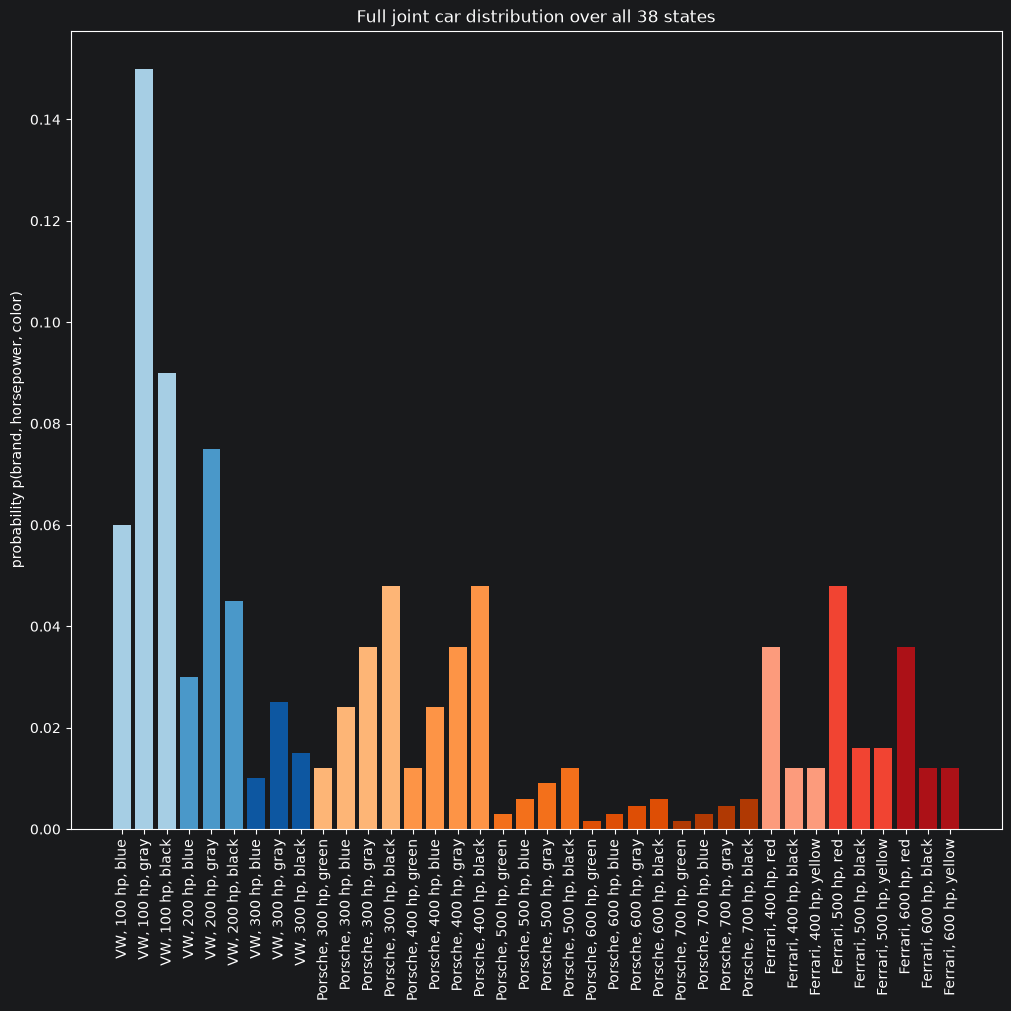

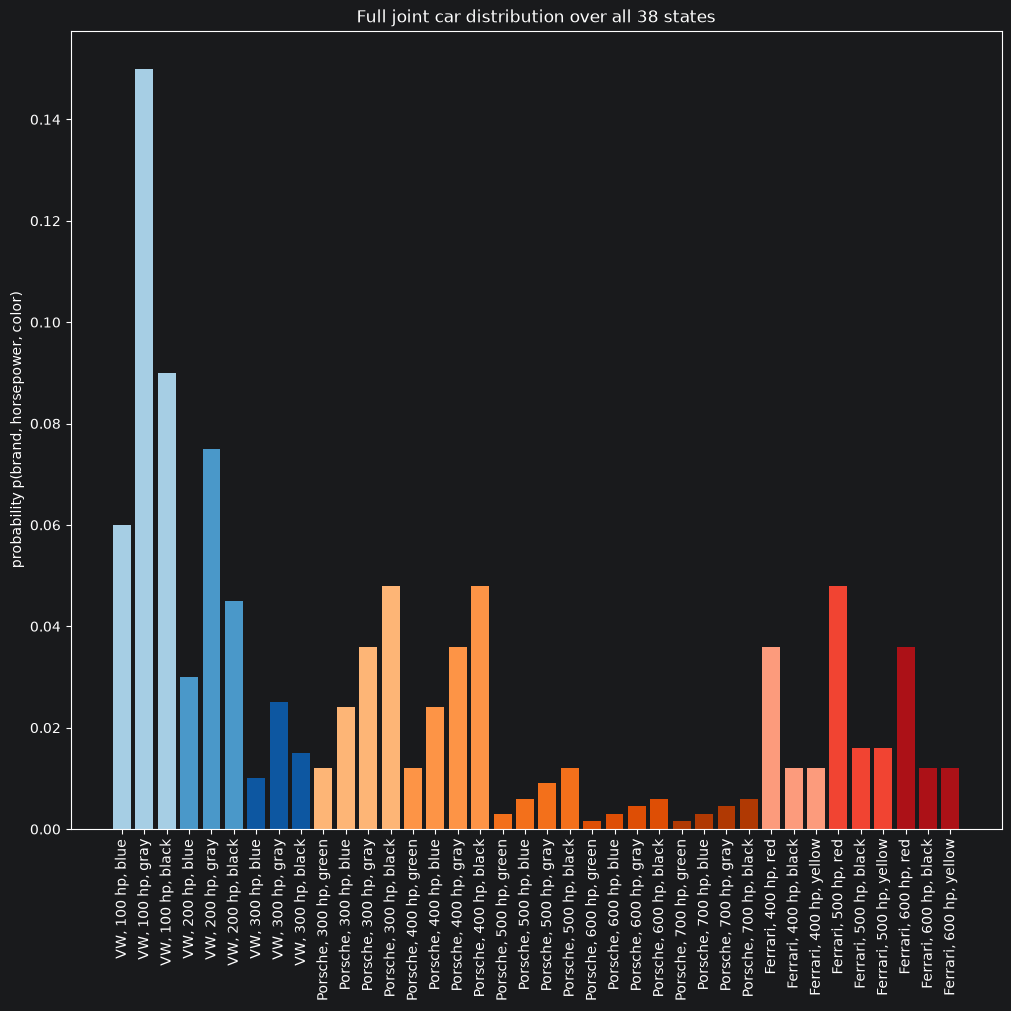

In [6]:
figure = visualize_joint_car_distribution_in_histogram()
figure

## References

- Blitzstein, J. K., Hwang, J. (2019): "Introduction to Probability", 2nd ed., Chapman & Hall/CRC, chapters "Random Variables and Their Distributions" and "Joint Distributions", https://www.routledge.com/Introduction-to-Probability-Second-Edition/Blitzstein-Hwang/p/book/9781138369917 (free PDF: https://probabilitybook.net/).
- Wasserman, L. (2004): "All of Statistics: A Concise Course in Statistical Inference", Springer Texts in Statistics, chapter "Probability", https://doi.org/10.1007/978-0-387-21736-9.
- scipy.stats.rv_discrete, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html.